In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from arch import arch_model

In [2]:
TICKERS = ["AAPL", "NVDA"]

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR  = REPO_ROOT / "data" / "raw"

COLORS = {
    "AAPL": "#1f77b4",   # blue
    "NVDA": "#2ca02c",   # green
}

In [3]:
def load_stock(ticker: str) -> pd.DataFrame:
    path = DATA_DIR / f"{ticker}_data.csv"
    return pd.read_csv(path, index_col="Date", parse_dates=True)

stock_data = {ticker: load_stock(ticker) for ticker in TICKERS}
stock_data["AAPL"].head()

,Open,High,Low,Close,Volume,Daily_Return,MA_20,MA_50,Volatility_20
Date,,,,,,,,,
2021-01-04,129.734330,129.821775,123.165994,125.740860,143301900,NaN,NaN,NaN,NaN
2021-01-05,125.235592,128.004792,124.788628,127.295479,97664900,0.012364,NaN,NaN,NaN
2021-01-06,124.098745,127.334331,122.796735,123.010498,155088000,-0.033662,NaN,NaN,NaN
2021-01-07,124.720594,127.897884,124.234771,127.208008,109578200,0.034123,NaN,NaN,NaN
2021-01-08,128.675231,128.869572,126.537610,128.306015,105158200,0.008632,NaN,NaN,NaN


## Fit GARCH(1,1)

`arch_model` expects returns scaled roughly to percent (e.g. 1.0 = 1%) for numerical stability, so we multiply `Daily_Return` by 100 before fitting.

In [4]:
garch_results = {}

for ticker, df in stock_data.items():
    returns_pct = df["Daily_Return"].dropna() * 100
    model = arch_model(returns_pct, vol="Garch", p=1, q=1, dist="t")
    result = model.fit(disp="off")
    garch_results[ticker] = result
    print(f"--- {ticker} ---")
    print(result.summary())
    print()

--- AAPL ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                 Daily_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2575.82
Distribution:      Standardized Student's t   AIC:                           5161.65
Method:                  Maximum Likelihood   BIC:                           5187.78
                                              No. Observations:                 1374
Date:                      Wed, Jul 08 2026   Df Residuals:                     1373
Time:                              14:21:23   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
------------------------------------------------------------------------

## Conditional volatility vs realized (rolling) volatility

GARCH's fitted conditional std (annualization not applied here, daily scale) compared against the 20-day rolling realized volatility from `basic_analysis.ipynb`.

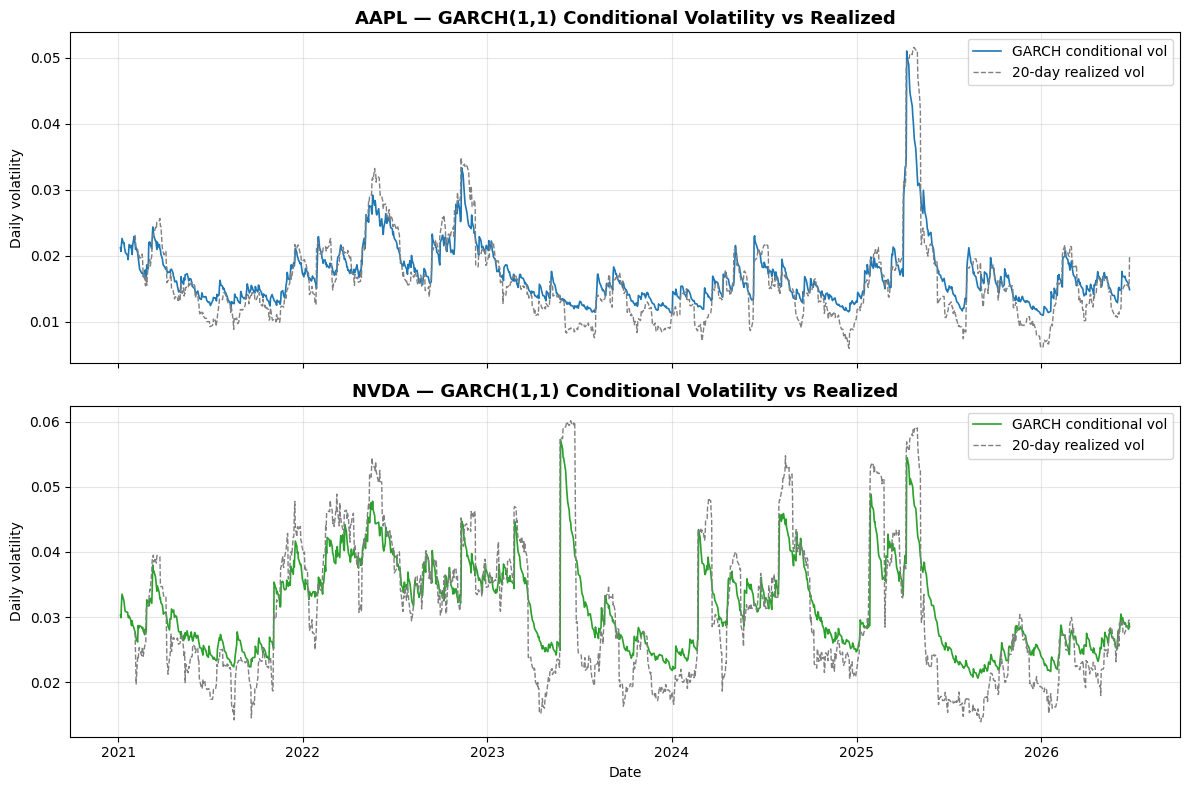

In [5]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 4 * len(TICKERS)), sharex=True)

for ax, (ticker, df) in zip(axes, stock_data.items()):
    result = garch_results[ticker]
    color = COLORS[ticker]

    cond_vol = result.conditional_volatility / 100  # back to return-fraction scale
    realized_vol = df["Daily_Return"].rolling(20).std()

    ax.plot(cond_vol.index, cond_vol, color=color, linewidth=1.2, label="GARCH conditional vol")
    ax.plot(realized_vol.index, realized_vol, color="gray", linewidth=1, linestyle="--", label="20-day realized vol")

    ax.set_title(f"{ticker} — GARCH(1,1) Conditional Volatility vs Realized", fontsize=13, fontweight="bold")
    ax.set_ylabel("Daily volatility")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.tight_layout()

## Forecast next N days of volatility

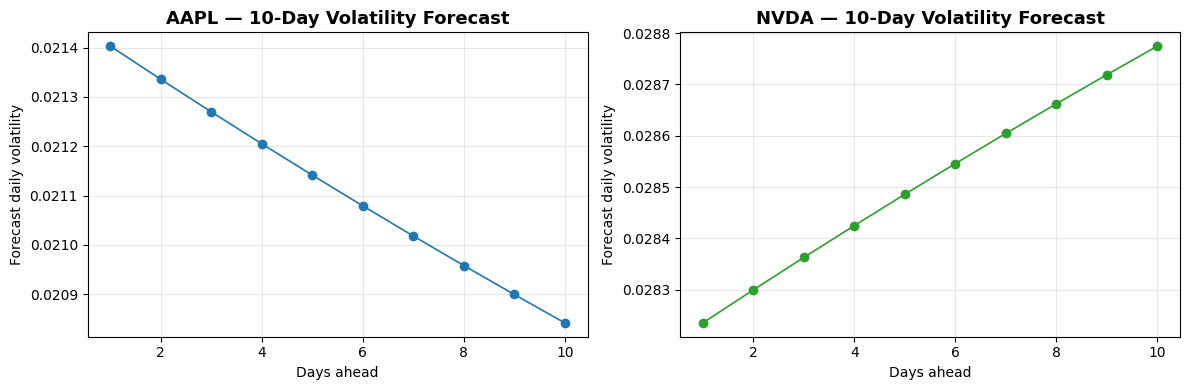

In [6]:
HORIZON = 10

fig, axes = plt.subplots(1, len(TICKERS), figsize=(12, 4))

for ax, (ticker, df) in zip(axes, stock_data.items()):
    result = garch_results[ticker]
    color = COLORS[ticker]

    forecast = result.forecast(horizon=HORIZON, reindex=False)
    forecast_vol = np.sqrt(forecast.variance.values[-1]) / 100  # daily return-fraction scale

    ax.plot(range(1, HORIZON + 1), forecast_vol, color=color, marker="o", linewidth=1.2)
    ax.set_title(f"{ticker} — {HORIZON}-Day Volatility Forecast", fontsize=13, fontweight="bold")
    ax.set_xlabel("Days ahead")
    ax.set_ylabel("Forecast daily volatility")
    ax.grid(True, alpha=0.3)

fig.tight_layout()